# RoadSafe NZ — Exploratory Data Analysis

Profiles the **cleaned** CAS dataset (after `clean_data.py`'s Null-string fix, coordinate reprojection, and `is_severe` target) before we lean further on the engineered features: how much is genuinely missing, whether there are duplicate records, what the numeric outliers look like, and how severity is distributed and trending over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_csv("../data/processed/cas_crash_data_clean.csv")
df.shape

(705609, 74)

## 1. Missing values

This is the *true* missing picture — it only counts real `NaN`, now that the disguised `"Null"` strings in `weatherA`/`weatherB`/`roadSurface`/`flatHill` have been converted.

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report[missing_report["missing_count"] > 0]

,missing_count,missing_pct
intersection,705609,100.0
crashRoadSideRoad,705609,100.0
temporarySpeedLimit,690852,97.9
weatherB,682094,96.7
pedestrian,681914,96.6
holiday,666835,94.5
guardRail,403996,57.3
fence,403996,57.3
cliffBank,403996,57.3
bridge,403996,57.3


A block of columns (`bridge`, `cliffBank`, `debris`, `ditch`, `fence`, `guardRail`, `houseOrBuilding`, `kerb`, `objectThrownOrDropped`, `otherObject`, `overBank`, `parkedVehicle`, `phoneBoxEtc`, `postOrPole`, `roadworks`, `slipOrFlood`, `strayAnimal`, `trafficIsland`, `trafficSign`, `train`, `tree`, `vehicle`, `waterRiver`) are all missing for the exact same ~57% of rows. That's not random sparsity — it's a schema change partway through CAS's history (these roadside-object columns were only recorded from a certain year onward). Worth confirming which `crashYear`s those come from before deciding how to handle them in modeling, rather than assuming MCAR (missing completely at random) and just imputing.

In [4]:
# Confirm the schema-change theory: which years have `bridge` populated?
df.loc[df["bridge"].notna(), "crashYear"].agg(["min", "max"])

min    2006
max    2026
Name: crashYear, dtype: int64

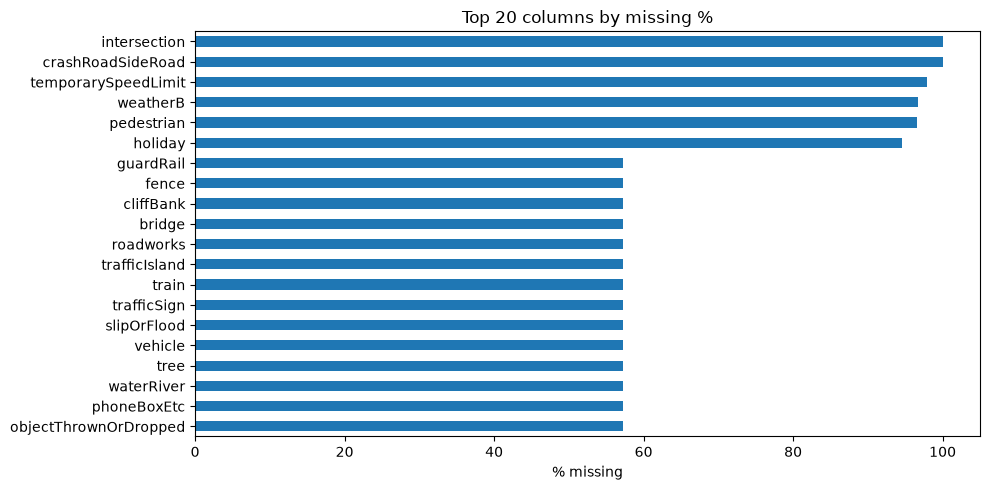

In [5]:
top_missing = missing_report[missing_report["missing_count"] > 0].head(20)
top_missing["missing_pct"].plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("% missing")
plt.title("Top 20 columns by missing %")
plt.tight_layout()
plt.show()

## 2. Duplicate records

`OBJECTID` should be a unique crash identifier — if it isn't, that's a data quality problem worth knowing about before we train anything on it.

In [6]:
full_dupes = df.duplicated().sum()
id_dupes = df.duplicated(subset=["OBJECTID"]).sum()
print(f"Fully duplicated rows: {full_dupes}")
print(f"Duplicate OBJECTID values: {id_dupes}")

Fully duplicated rows: 0
Duplicate OBJECTID values: 0


## 3. Outliers in numeric fields

Using the standard IQR rule (outside `Q1 - 1.5*IQR` to `Q3 + 1.5*IQR`) — but treat the result as a prompt to look closer, not an automatic drop list. `speedLimit` is a posted speed limit, not a sensor reading: low values like 2 or 10 km/h are legitimate (carparks, shared zones), so IQR will flag real, valid crashes as "outliers" here.

In [7]:
def iqr_outlier_report(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    pct = len(outliers) / series.notna().sum() * 100
    print(f"{name}: IQR bounds=({lower:.1f}, {upper:.1f}), "
          f"outliers={len(outliers)} ({pct:.2f}%)")

iqr_outlier_report(df["speedLimit"].dropna(), "speedLimit")
iqr_outlier_report(df["NumberOfLanes"].dropna(), "NumberOfLanes")
iqr_outlier_report(df["fatalCount"].dropna(), "fatalCount")
iqr_outlier_report(df["seriousInjuryCount"].dropna(), "seriousInjuryCount")

speedLimit: IQR bounds=(-25.0, 175.0), outliers=0 (0.00%)
NumberOfLanes: IQR bounds=(2.0, 2.0), outliers=170310 (24.22%)
fatalCount: IQR bounds=(0.0, 0.0), outliers=6182 (0.88%)
seriousInjuryCount: IQR bounds=(0.0, 0.0), outliers=42930 (6.09%)


## 4. Severity distribution

The four raw `crashSeverity` categories, and the binary `is_severe` target derived from them.

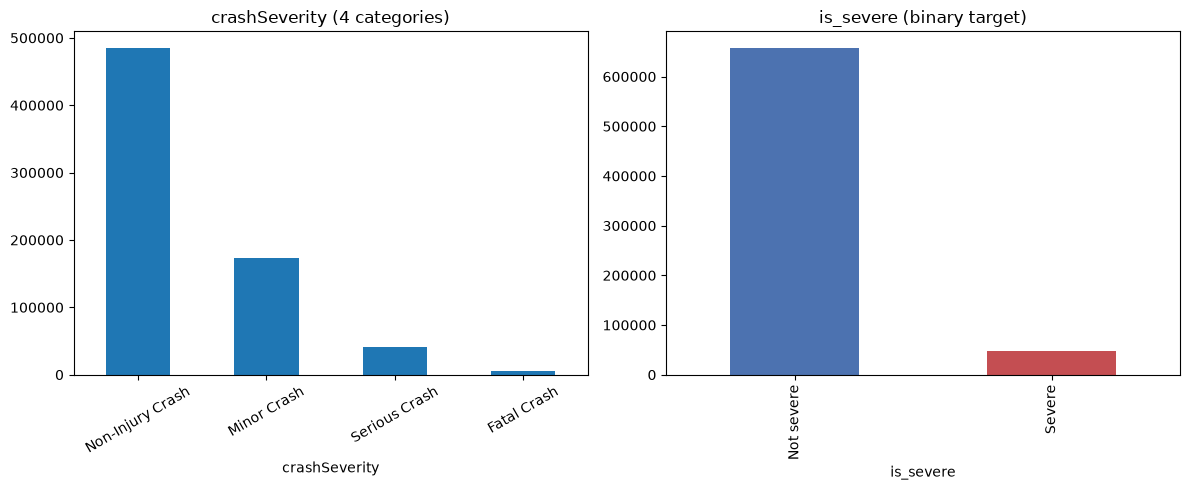

is_severe
False    0.93276
True     0.06724
Name: proportion, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["crashSeverity"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("crashSeverity (4 categories)")
axes[0].tick_params(axis="x", rotation=30)

df["is_severe"].value_counts().rename({True: "Severe", False: "Not severe"}).plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"]
)
axes[1].set_title("is_severe (binary target)")

plt.tight_layout()
plt.show()

df["is_severe"].value_counts(normalize=True)

## 5. Trends over time

⚠️ Today's date is 2026-09-07, so **`crashYear` 2026 is a partial year** — it will show an artificially low crash count next to complete years. Excluding it from the trend line (but keeping it in the table) avoids a misleading dip at the end of the chart.

In [9]:
yearly = df.groupby("crashYear").agg(
    total_crashes=("OBJECTID", "count"),
    severe_rate=("is_severe", "mean"),
)
yearly

,total_crashes,severe_rate
crashYear,,
2006,39778,0.063678
2007,41661,0.060992
2008,39535,0.062603
2009,38247,0.060972
2010,36870,0.060184
2011,32450,0.061695
2012,30443,0.066518
2013,30109,0.063868
2014,29784,0.067117


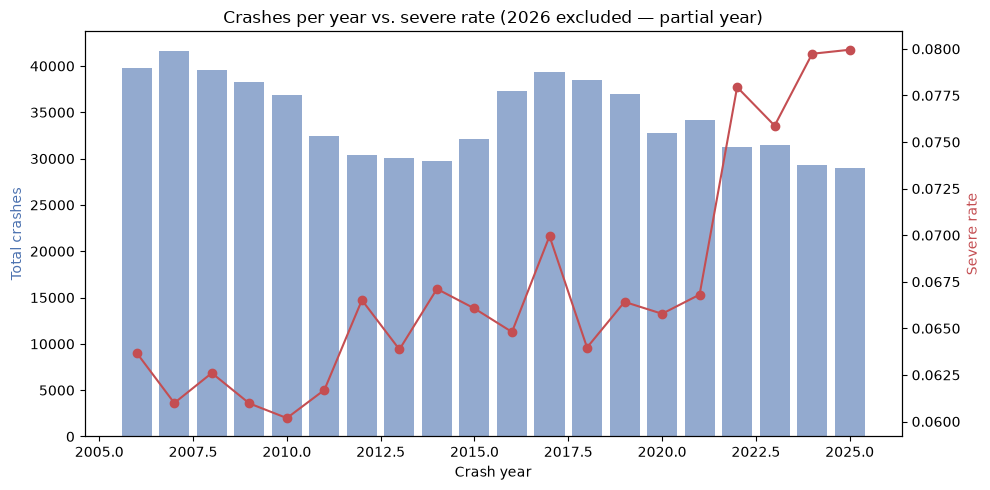

In [10]:
complete_years = yearly.drop(index=2026)

fig, ax1 = plt.subplots()
ax1.bar(complete_years.index, complete_years["total_crashes"], color="#4C72B0", alpha=0.6)
ax1.set_ylabel("Total crashes", color="#4C72B0")
ax1.set_xlabel("Crash year")

ax2 = ax1.twinx()
ax2.plot(complete_years.index, complete_years["severe_rate"], color="#C44E52", marker="o")
ax2.set_ylabel("Severe rate", color="#C44E52")

plt.title("Crashes per year vs. severe rate (2026 excluded — partial year)")
plt.tight_layout()
plt.show()

## 6. Severity by weather and road surface

A first look at whether the conditions we engineered features from actually move the severity rate — a sanity check on Phase 3, run backwards.

In [11]:
weather_severity = df.groupby("weatherA")["is_severe"].agg(["mean", "count"]).sort_values("mean", ascending=False)
weather_severity

,mean,count
weatherA,,
Mist or Fog,0.075570,9951
Hail or Sleet,0.074074,216
Fine,0.071539,549111
Heavy rain,0.057016,26712
Snow,0.056291,1208
Light rain,0.054630,103131


In [12]:
surface_severity = df.groupby("roadSurface")["is_severe"].agg(["mean", "count"]).sort_values("mean", ascending=False)
surface_severity

,mean,count
roadSurface,,
End of seal,0.156425,179
Unsealed,0.129143,14333
Sealed,0.066086,689390


## Takeaways

- **Found and fixed a real bug in `clean_data.py` while running this EDA**: the disguised `"Null"` string bug (documented for `weatherA`/`weatherB`/`roadSurface`/`flatHill`) also affected `crashDirectionDescription` (37.1% of rows!), `streetLight` (33.3% of rows on top of its already-known missingness), `directionRoleDescription` (0.6%), and `roadLane` (0.1%) — found by scanning every object column in the raw data for the literal string "Null" instead of trusting the original 4-column list. `clean_data.py`'s `NULL_STRING_COLUMNS` now covers all 8. This notebook reflects the corrected data.
- **`streetLight` is far more sparse than it first appeared**: after the fix, it's 50.5% missing (not the 17.3% first reported) — the disguised "Null" strings were masking most of the real gap.
- **`intersection` and `crashRoadSideRoad` are 100% empty** (0 non-null values across all 705,609 rows) — dead columns, should be dropped in `clean_data.py` rather than carried forward.
- **The mid-history schema-change theory was wrong** for the 57.3%-missing roadside-object block (`bridge`, `fence`, `tree`, `vehicle`, etc.): `bridge` is populated across the full crashYear range (2006–2026), not a subset. NaN in these columns most likely means "this object was not involved," i.e. functionally 0 — not "not recorded." Decision needed before modeling: fill with 0 rather than drop or impute as missing. Logged in DECISIONS.md as still open.
- **No duplicates**: 0 fully duplicated rows, 0 duplicate `OBJECTID` values — no dedup step needed.
- **IQR outlier detection doesn't suit these columns.** `NumberOfLanes` flags ~24% of rows as "outliers" purely because the IQR window collapses to (2.0, 2.0) when the value is overwhelmingly 2 — not a real anomaly. Same issue with `fatalCount`/`seriousInjuryCount`, where 0 is the dominant value so any nonzero count reads as an "outlier." Not treated as a data quality problem.
- **Severe rate is trending up.** From ~6.0–6.7% through 2006–2021, severe rate rose to 7.8% (2022), 7.6% (2023), 8.0% (2024), 8.0% (2025). 2026 is a partial year (14,573 crashes vs ~30–40k in complete years) so its 8.7% isn't directly comparable yet, but the 2022–2025 shift looks real — supports the roadmap's preference for a chronological train/test split over a random one.
- **Counterintuitive weather finding**: "Fine" weather crashes are *more* likely to be severe (7.15%) than rain (Light rain 5.46%, Heavy rain 5.70%). Plausible explanation: bad weather suppresses speed and crash energy even though it may not reduce crash frequency — a good interview talking point (data contradicts the naive assumption that bad-weather crashes are worse).
- **Road surface confirms the `road_hazard_score` assumption**: Sealed roads have a 6.6% severe rate vs. 12.9% on Unsealed (n=14,333) and 15.6% at "End of seal" transitions (n=179, small sample). Re-running feature_engineering.py after the Null-string fix also shows `road_hazard_score` tracking severity cleanly: 5.7% (score 0) up to 10.0% (score 5) — validates keeping it as a feature.
